In [21]:
from qiskit import QuantumCircuit, transpile
from qiskit.primitives import StatevectorSampler
import matplotlib as plt
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
import numpy as np

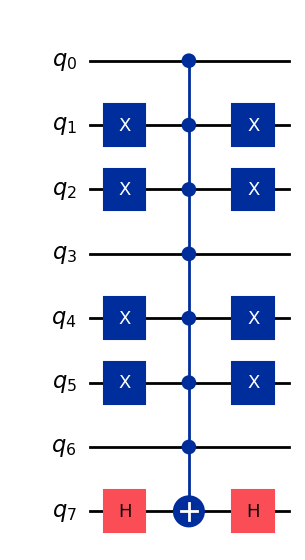

In [22]:
target ='11001001'

#oracle
def quantum_oracle(target):
    oracle = QuantumCircuit(len(target), name='Oracle')

    #menerapkan X-gate setiap menemukan |0>
    for i, bit in enumerate(reversed(target)):
        if bit == '0':
            oracle.x(i)

    #menerapkan multi controlled Z-gate untuk setiap qubit
    oracle.h(len(target)-1)
    oracle.mcx(list(range(len(target)-1)), len(target)-1)
    oracle.h(len(target)-1)

    #menerapkan X-gate untuk menemukan |0>
    for i, bit in enumerate(reversed(target)):
        if bit == '0':
            oracle.x(i)

    #membuat black box
    #oracle.to_gate()

    return oracle

quantum_oracle(target).draw('mpl')
    

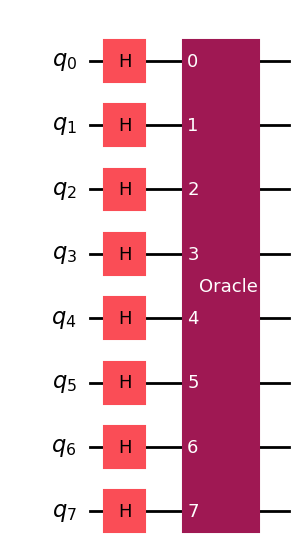

In [24]:
gc = QuantumCircuit(len(target))
gc.h(list(range(len(target))))
gc.append(quantum_oracle(target), list(range(len(target))))

gc.draw('mpl')